# Acoustic Contour Metric Convergence Analysis

This notebook validates the convergence of acoustic contour metrics with respect to number of revolutions and observation times per revolution.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
from FastBEMT.DataLoader import load_propeller_dict
from LFProp.Utils import get_oaspl_contour_area
import scienceplots

plt.style.use(['science', 'no-latex'])

In [2]:
# Load propeller geometry
prop_name, blade_dict = load_propeller_dict('APC Dicts/10x7E')[0]

# Define observer grid
n_observers_per_side = 16
size = 5
x_range = np.linspace(-size, size, n_observers_per_side)
y_range = np.linspace(0, size, n_observers_per_side)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X)
r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

print(f'Observer grid: {n_observers_per_side} x {n_observers_per_side} = {len(r_observers)} observers')

Observer grid: 16 x 16 = 256 observers


In [3]:
# Test parameter ranges
revolutions_range = np.linspace(1, 10, 10, dtype=int)
num_obs_times_per_rev_range = np.linspace(10, 100, 10, dtype=int)

# Storage for results
oaspl_values = {}  # Dictionary: (revs, num_obs) -> OASPL array
computation_times = {}  # Dictionary: (revs, num_obs) -> time in seconds

print('Running convergence analysis...')
print(f'Testing {len(revolutions_range)} revolutions x {len(num_obs_times_per_rev_range)} obs_times configurations')
print()

for revolutions in revolutions_range:
    for num_obs_times_per_rev in num_obs_times_per_rev_range:
        params = LowFidelityParameters(
            rpm=7000,
            a_inf=343,
            rho=1.225,
            mu=1.81e-5,
            n_blades=blade_dict['n_blades'],
            p_ref=2e-5,
            revolutions=revolutions,
            num_obs_times_per_rev=num_obs_times_per_rev,
            device='cuda',
        )
        
        propeller = Propeller(
            geometry=blade_dict,
            params=params,
        )
        
        # Run BEMT
        propeller.run_bemt(v_inf=0.0)
        
        # Run aeroacoustics
        propeller.run_aeroacoustics(
            observer_positions=r_observers,
            lt=1,
            i=1e-3,
            alpha_stall=15,
            keep_bpm_components=False
        )
        propeller.postprocess()

        propeller.third_octave_total_oaspl = propeller.third_octave_total_oaspl.reshape(n_observers_per_side, n_observers_per_side)
        propeller.third_octave_total_oaspl = np.vstack([
            propeller.third_octave_total_oaspl[::-1, :],     # Flip for negative y
            propeller.third_octave_total_oaspl[1:, :]        # Original positive y, skip y=0 to avoid duplication
        ])
        # Store results
        key = (revolutions, num_obs_times_per_rev)
        area = get_oaspl_contour_area(propeller, target_level=60, size=size, weight_below=1)
        oaspl_values[key] = area
        
        # Calculate mean OASPL for reference
        print(f'revolutions={revolutions:2d}, num_obs_times_per_rev={num_obs_times_per_rev:3d} -> '
              f'Contour Area={area:.2f} dB(A)')


Running convergence analysis...
Testing 10 revolutions x 10 obs_times configurations

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 77.928 ms


C:\Users\dpusino\Desktop\FastBEMT\src\FastBEMT\BPM.py:844: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self.u = torch.as_tensor(u, dtype=self.dtype, device=self.device)


[CUDA TIMING] BPM.__init__: 6.539 ms
[CUDA TIMING] get_observer_times: 14.651 ms
[CUDA TIMING] calculate_f1a_pressure: 31.546 ms
[CUDA TIMING] combine_sources (F1A): 19.101 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 87.841 ms
[CUDA TIMING] BPM.run_forward_bpm: 42.853 ms
[CUDA TIMING] combine_sources_bpm: 0.476 ms
revolutions= 1, num_obs_times_per_rev= 10 -> Contour Area=24.35 dB(A)
[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 1.490 ms
[CUDA TIMING] BPM.__init__: 1.089 ms
[CUDA TIMING] get_observer_times: 0.266 ms
[CUDA TIMING] calculate_f1a_pressure: 4.796 ms
[CUDA TIMING] combine_sources (F1A): 1.155 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 14.482 ms
[CUDA TIMING] BPM.run_forward_bpm: 29.888 ms
[CUDA TIMING] combine_sources_bpm: 0.391 ms
revolutions= 1, num_obs_times_per_rev= 20 -> Contour Area=24.36 dB(A)
[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 1.203 ms
[CUDA TIMING] BPM.__init__: 1.206 ms
[CUDA TIMING] get_observer_times: 0.470 ms
[CUDA T

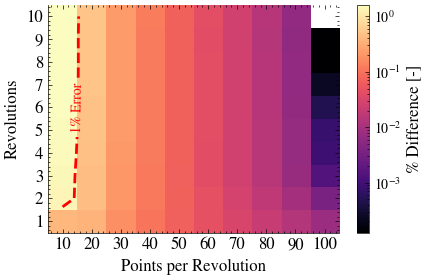

In [7]:
from matplotlib.colors import LogNorm, PowerNorm

# Create 2D heatmap: revolutions vs points_per_rev, colored by difference from reference
ref_key = (revolutions_range[-1], num_obs_times_per_rev_range[-1])
ref_value = oaspl_values[ref_key]

# Create 2D array for heatmap
heatmap_data = np.zeros((len(revolutions_range), len(num_obs_times_per_rev_range)))

for i, revolutions in enumerate(revolutions_range):
    for j, num_obs_times in enumerate(num_obs_times_per_rev_range):
        key = (revolutions, num_obs_times)
        heatmap_data[i, j] = 100 * np.abs((oaspl_values[key] - ref_value) / ref_value)

# Create figure and heatmap
fig, ax = plt.subplots(figsize=(4.5, 3))

# Plot heatmap
im = ax.imshow(
    heatmap_data,
    cmap='magma',
    norm=LogNorm(vmin=heatmap_data[heatmap_data > 0].min(), vmax=heatmap_data.max()), # Use LogNorm
    aspect='auto',
    origin='lower',
    interpolation='nearest'
)
X, Y = np.meshgrid(np.arange(len(num_obs_times_per_rev_range)), 
                   np.arange(len(revolutions_range)))

contour = ax.contour(X, Y, heatmap_data, levels=[1], 
                     colors='red', linestyles='--', linewidths=2)

ax.clabel(contour, inline=True, fmt='1%% Error', fontsize=10)

# Set ticks and labels
ax.set_xticks(np.arange(len(num_obs_times_per_rev_range)))
ax.set_yticks(np.arange(len(revolutions_range)))
ax.set_xticklabels(num_obs_times_per_rev_range, fontsize=12)
ax.set_yticklabels(revolutions_range, fontsize=12)

# Labels and formatting
ax.set_xlabel('Points per Revolution', fontsize=12)
ax.set_ylabel('Revolutions', fontsize=12)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('% Difference [-]', fontsize=12)

# Remove top and right spines
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../Figures/Validation/convergence_2d_heatmap.pdf', dpi=200)
plt.show()